# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
df = pd.read_csv('../data/checker_regression.csv')
df = df.drop(columns=['uid']).fillna(0).drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


In [3]:
X = df.drop(columns=['AVG(diff)'])
y = df['AVG(diff)']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=21, random_state=21
)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [5]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits)
    test_accuracy = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)

        train_score = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
        test_score = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
        test_accuracy.append(test_score)
        print(f'train - {train_score}  |  test  - {test_score}')
    
    print(f'Average RMSE on crossval is {np.mean(test_accuracy)}')       


In [6]:
linreg_model = LinearRegression(fit_intercept=True)
tree_model = DecisionTreeRegressor(random_state=21, max_depth = 7)
forest_model = RandomForestRegressor(random_state=21, n_estimators=100, max_depth=10)

In [7]:
crossval(10, X, y, linreg_model)

train - 61.0609013662618  |  test  - 63.829848149049276
train - 63.988158740733866  |  test  - 20.035391040948973
train - 62.20348097704721  |  test  - 51.2396392164924
train - 60.15245489851986  |  test  - 68.19025234463642
train - 60.619323028395335  |  test  - 65.92296908962915
train - 56.16434140855645  |  test  - 95.44112210462167
train - 62.829271732704264  |  test  - 42.53528614164396
train - 58.9639828974483  |  test  - 88.68458481189293
train - 59.97579900754424  |  test  - 72.7480702154982
train - 59.6927079308268  |  test  - 78.6490932726747
Average RMSE on crossval is 64.72762563870876


In [8]:
crossval(10, X, y, tree_model)

train - 2.18413202263684  |  test  - 47.34272207354931
train - 0.0  |  test  - 75.18237825448195
train - 0.0  |  test  - 78.98656472722058
train - 0.0  |  test  - 56.503346344691366
train - 2.18413202263684  |  test  - 35.38836908740875
train - 2.7599131737240805  |  test  - 104.28651416667947
train - 2.18413202263684  |  test  - 99.13004739379627
train - 0.0  |  test  - 62.873444314750245
train - 0.0  |  test  - 84.88242249222243
train - 0.0  |  test  - 123.85033306374271
Average RMSE on crossval is 76.84261419185431


In [9]:
crossval(10, X, y, forest_model)

train - 23.376588725112924  |  test  - 54.188682625310854
train - 24.786329836610147  |  test  - 51.43619912958321
train - 23.572511158674967  |  test  - 78.22862076797261
train - 26.323072156014952  |  test  - 46.58363167823367
train - 23.84950304426348  |  test  - 53.93331786876579
train - 22.641636132615332  |  test  - 81.48666845609826
train - 22.829456547291223  |  test  - 85.3559750485078
train - 24.94655657217563  |  test  - 55.465009767253115
train - 23.615772901496197  |  test  - 58.201884439709815
train - 23.172034433072298  |  test  - 94.73684722371169
Average RMSE on crossval is 65.96168370051468


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [10]:
linreg_model.fit(X_train, y_train)
linreg_predict = linreg_model.predict(X_test)
linreg_predict

array([ -83.93637075,  -89.04309317, 2098.52430597,  -87.34085236,
       3405.45053056,  -85.63861156, 7676.27351012, 3552.55593419,
         -9.87299669,  -85.29816339,  592.11510257,  -80.87233729,
        -79.51054464,  -95.85205641,  -74.40382222,  150.79889168,
        -91.08578214,  -73.38247773, 1060.61572467,  279.52009458,
       4279.91219647])

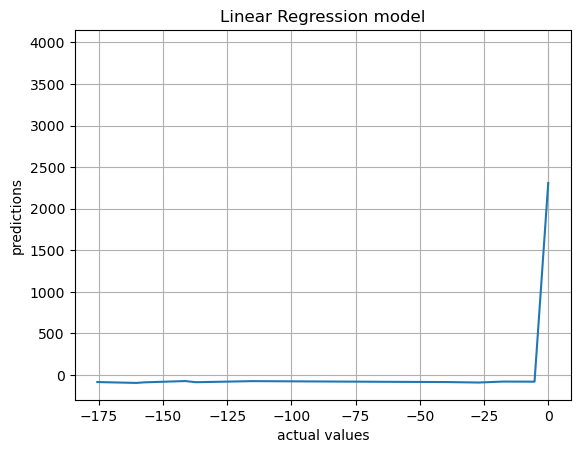

In [11]:
ax = sns.lineplot(x=y_test, y=linreg_predict)
ax.set_xlabel('actual values')
ax.set_ylabel('predictions')
ax.set_title('Linear Regression model')
ax.grid()

In [12]:
tree_model.fit(X_train, y_train)
tree_predict = tree_model.predict(X_test)
tree_predict

array([-223.6 ,  -48.5 ,    0.  ,  -48.5 ,  -48.5 , -223.6 ,    0.  ,
        -48.5 , -223.6 , -223.6 ,  -48.5 , -223.6 ,  -62.6 ,  -89.  ,
         -2.  ,  -48.5 ,  -48.5 ,  -84.  ,  -48.5 , -104.75,  -89.  ])

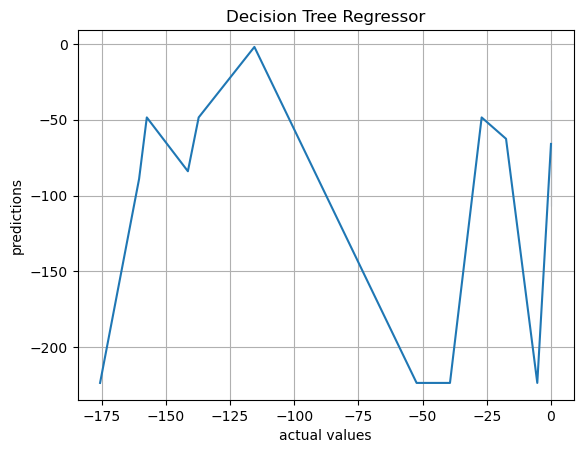

In [13]:
ax = sns.lineplot(x=y_test, y=tree_predict)
ax.set_xlabel('actual values')
ax.set_ylabel('predictions')
ax.set_title('Decision Tree Regressor')
ax.grid()

In [14]:
forest_model.fit(X_train, y_train)
forest_predict = forest_model.predict(X_test)
forest_predict

array([-151.855 ,  -93.238 ,  -36.381 ,  -87.068 ,  -80.921 , -151.855 ,
        -36.381 ,  -80.921 , -139.713 , -151.855 ,  -63.423 , -152.298 ,
        -91.118 ,  -90.058 ,  -30.702 ,  -63.423 ,  -93.238 ,  -37.482 ,
        -80.921 ,  -91.274 ,  -80.1245])

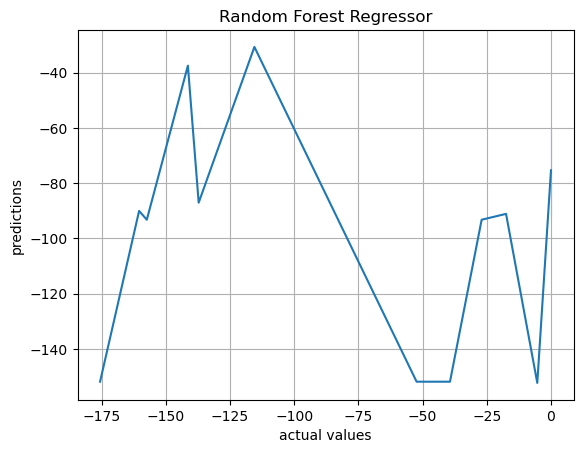

In [15]:
ax = sns.lineplot(x=y_test, y=forest_predict)
ax.set_xlabel('actual values')
ax.set_ylabel('predictions')
ax.set_title('Random Forest Regressor')
ax.grid()

Answer: diagonal